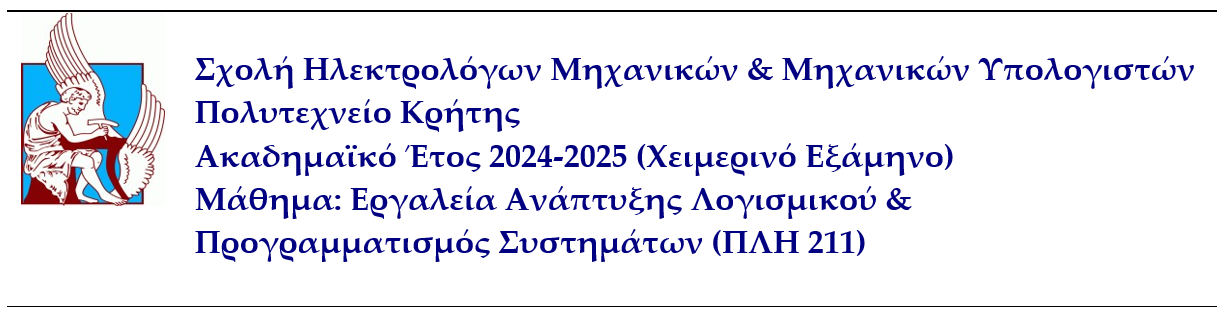

# Aggregative Movie Preference Analyzer

# Development Phase (30%)

## ⏩ Κώδικας Development Phase
Γράψτε στο παρακάτω code cell όλο τον κώδικα που υλοποιεί τον Aggregative Movie Preference Analyzer σας.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# %cd drive/MyDrive/

!cp /content/drive/MyDrive/movies.dat /content
!cp /content/drive/MyDrive/ratings.dat /content
!cp /content/drive/MyDrive/ratings_sho.dat /content

Mounted at /content/drive


In [ ]:
import math

def print_menu():
  print("Menu:")
  print("1. rating T1 T2")
  print("2. top_movies K")
  print("3. user_pairs K")
  print("4. dominance")
  print("5. iceberg K T")
  print("6. top_users K")
  print("7. movie_sample S")
  print("8. similar_users Θ")
  print("9. quit")
  print("")


def load_ratings(file_path):
  """
  Receives the path for a ratings file.
  Returns four dictionaries with organized data from the file.
  """

  movie_reviewers = {}  # movie: list of users
  movie_ratings = {}    # movie: list of ratings
  user_ratings = {}     # user:  list of (movie, rating) tuples
  movie_raters = {}     # movie:  list of (user, rating) tuples

  with open(file_path, 'r') as ratings_file:
    for line in ratings_file:
      user_id, movie_id, rating, timestamp = line.split("::")
      rating = float(rating)
      user_id = int(user_id)
      movie_id = int(movie_id)

      if movie_id not in movie_ratings:
        movie_ratings[movie_id] = []
        movie_reviewers[movie_id] = []
        movie_raters[movie_id] = []
      movie_ratings[movie_id].append(rating)
      movie_reviewers[movie_id].append(user_id)
      movie_raters[movie_id].append((user_id, rating))

      if user_id not in user_ratings:
        user_ratings[user_id] = []
      user_ratings[user_id].append((movie_id, rating))

  return movie_reviewers, movie_ratings, user_ratings, movie_raters


def load_movies(file_path):
  """
  Receives the path for a movies file.
  Returns a dictionary with organized data from the file.
  """
  movies = {}

  with open(file_path, 'r') as movies_file:
    for line in movies_file:
      movie_id, title, genres = line.split("::")
      genres = genres.strip().split("|")
      movie_id = int(movie_id)

      movies[movie_id] = {
        'title': title,
        'genres': genres
      }

    return movies


def rating_stats(movie_ratings):
  """
  Receives a dictionary with movie ratings.
  Returns a dictionary with the average rating and the number of ratings for each movie.
  """
  stats = {movie_id: (sum(ratings_list) / len(ratings_list), len(ratings_list))
    for movie_id, ratings_list in movie_ratings.items()}

  return stats


def rating(T1, T2, avg_ratings, movies):
  """
  Returns a list of movies with an average rating between T1 (inclusive) and T2 (exlusive)
  """

  if not (0.0 <= T1 <= 5.0 and 0.0 <= T2 <= 5.0) or T1 > T2:
    raise ValueError

  result = []
  for movie, stats in avg_ratings.items():
    avg_rating = stats[0]
    if T1 < avg_rating <= T2:
      result.append((movies[movie]['title'], avg_rating))
  return result


def top_movies(k, avg_ratings, movies):
  """
  Returns the top K movies with the highest average rating
  """

  if k <= 0:
    raise ValueError

  top_movies = sorted(avg_ratings.items(), key=lambda item: item[1][0], reverse=True)[:k]

  result = [(movies[movie_id]['title'], stats[0]) for movie_id, stats in top_movies]

  return result


def user_pairs(k, movie_reviewers, movies):
  """
  Finds pairs of users who have rated the same movie.
  """

  if k <= 0:
    raise ValueError

  pairs = []

  for movie_id, users in movie_reviewers.items():

    for i in range(len(users)):
      for j in range(i + 1, len(users)):
        user1 = users[i]
        user2 = users[j]
        pairs.append((user1, user2, movies[movie_id]['title']))

        if len(pairs) >= k:
          return pairs

  return pairs


def dominance(average_ratings, movies):
  """
  Finds movies that are not dominated by other movies.
  """
  non_dominated = []

  movie_ids = list(average_ratings.keys())

  for movie1 in movie_ids:
    avg_rating1, num_reviews1 = average_ratings[movie1]
    dominated = False

    for movie2 in movie_ids:
      if movie1 != movie2:  # Don't compare the movie with itself
        avg_rating2, num_reviews2 = average_ratings[movie2]

        # Check if movie1 is dominated by movie2
        if avg_rating1 <= avg_rating2 and num_reviews1 <= num_reviews2:
          dominated = True
          break  # No need to check further

    if not dominated:
      non_dominated.append((movies[movie1]['title'], avg_rating1, num_reviews1))

  return non_dominated


def iceberg(K, T, avg_ratings, movies):
  """
  Finds movies with at least K reviews and an average rating greater than T.
  """

  if K <= 0 or not (0.0 <= T <= 5.0):
    raise ValueError

  result = [
    (movies[movie_id]['title'], stats[0], stats[1])
    for movie_id, stats in avg_ratings.items()
    if stats[1] >= K and stats[0] > T
  ]

  return result


def top_users(K, user_ratings):
  """
  Finds the top K users with the highest number of ratings.
  """

  if K <= 0:
    raise ValueError

  # Count the number of ratings each user has made
  user_count = {user: len(movie_list) for user, movie_list in user_ratings.items()}

  # Sort users by their rating count in descending order and select the top K
  sorted_users = sorted(user_count.items(), key=lambda x: x[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users


def movie_sample(S, movies):
  """
  Returns a dictionary with a sample of S% of movies for each genre.
  """

  if S <= 0:
    raise ValueError

  genre_samples = {}

  # Organize movies by genre
  genres = {}
  for movie_id, data in movies.items():
    for genre in data['genres']:
      if genre not in genres:
        genres[genre] = []
      genres[genre].append(data['title'])

  # Take a sample of S% from each genre
  for genre, movie_list in genres.items():
    sample_size = int(len(movie_list) * S / 100)
    genre_samples[genre] = movie_list[:sample_size]

  return genre_samples


def similar_users(theta, movie_ratings):
  """
  Returns a list of similar users based on the cosine similarity of their ratings.
  """

  if not (-1 <= theta <= 1):
    raise ValueError

  user_pair_dot_products = {}
  user_pair_magnitudes = {}

  similar_users = []

  # Iterate through movies and compare user pairs
  for movie, raters in movie_ratings.items():
    # Compare every pair of users who rated the movie
    for i in range(len(raters)):
      for j in range(i + 1, len(raters)):
        user1, rating1 = raters[i]
        user2, rating2 = raters[j]

        # Avoid pair duplicates
        if user1 > user2:
          user1, user2 = user2, user1

        # Update dot product and magnitudes
        if (user1, user2) not in user_pair_dot_products:
          user_pair_dot_products[(user1, user2)] = 0
          user_pair_magnitudes[(user1, user2)] = (0, 0)
        user_pair_dot_products[(user1, user2)] += rating1 * rating2
        r1, r2 = user_pair_magnitudes[(user1, user2)]
        user_pair_magnitudes[(user1, user2)] = (r1 + (rating1**2), r2 + (rating2**2))

  # Compute similarity
  for (user1, user2), dot_product in user_pair_dot_products.items():
    magnitudes = user_pair_magnitudes[(user1, user2)]
    magnitude1 = math.sqrt(magnitudes[0])
    magnitude2 = math.sqrt(magnitudes[1])
    similarity = dot_product / (magnitude1 * magnitude2)

    # If similarity meets the threshold, add it to the result
    if similarity >= theta:
      similar_users.append((user1, user2, similarity))

  # Sort results by similarity in descending order
  similar_users.sort(key=lambda x: x[2], reverse=True)
  return similar_users


def main():
  ratings_file = "ratings_sho.dat"
  movies_file = "movies.dat"

  movie_reviewers, movie_ratings, user_ratings, movie_raters = load_ratings(ratings_file)
  movies = load_movies(movies_file)

  while True:
    print_menu()
    command = input("Enter command: ").strip()

    if command.startswith("rating"):
      try:
        T1, T2 = map(float, command.split()[1:])

        result = rating(T1, T2, rating_stats(movie_ratings), movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating")
        print(f"{'-' * 11:<{max_title_length}}    {'-' * 14}")
        for movie, avg_rating in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:.1f}")
      except (ValueError, IndexError):
        print("Invalid arguments for 'rating'.")

    elif command.startswith("top_movies"):
      try:
        K = int(command.split()[1])
        result = top_movies(K, rating_stats(movie_ratings), movies)
        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating")
        print(f"{'-' * 11:<{max_title_length}}    {'-' * 14}")
        for movie, avg_rating in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:.1f}")
      except (ValueError, IndexError):
        print("Invalid argument for 'top_movies'.")

    elif command.startswith("user_pairs"):
      try:
        K = int(command.split()[1])
        result = user_pairs(K, movie_reviewers, movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User 1        User 2        Movie title")
        print('------        ------        -----------')
        for user1, user2, movie in result:
          print(f"{user1:<10}    {user2:<10}    {movie}")
      except (ValueError, IndexError):
        print("Invalid argument for 'user_pairs'.")

    elif command.startswith("dominance"):
      result = dominance(rating_stats(movie_ratings), movies)

      # Print result
      max_title_length = max(len(movie) for movie, _, _ in result)
      print(f"{'Movie title':<{max_title_length}}    Average Rating    Number of Reviews")
      print(f"{'-' * len('Movie title'):<{max_title_length}}    {'-' * 14}    {'-' * 17}")
      for movie, avg_rating, review_num in result:
        print(f"{movie:<{max_title_length}}    {avg_rating:<14.2f}    {review_num}")

    elif command.startswith("iceberg"):
      try:
        K, T = map(float, command.split()[1:])
        result = iceberg(K, T, rating_stats(movie_ratings), movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating    Number of Reviews")
        print(f"{'-' * len('Movie title'):<{max_title_length}}    {'-' * 14}    {'-' * 17}")
        for movie, avg_rating, review_num in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:<14.1f}    {review_num}")
      except (ValueError, IndexError):
        print("Invalid arguments for 'iceberg'.")

    elif command.startswith("top_users"):
      try:
        K = int(command.split()[1])
        result = top_users(K, user_ratings)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User          Number of Reviews")
        print('----          -----------------')
        for user, review_num in result:
          print(f"{user:<10}    {review_num}")
      except (ValueError, IndexError):
        print("Invalid argument for 'top_users'.")

    elif command.startswith("movie_sample"):
      try:
        S = float(command.split()[1])
        result = movie_sample(S, movies)

        if result == {}:
          print("No results found.\n")
          continue

        # Print result
        print("Genre                   Movie Titles")
        print('-----                   ------------')
        for genre, movies_list in result.items():
          movies_list = ", ".join(movies_list)
          print(f"{genre:<20}    {movies_list}")
      except (ValueError, IndexError):
        print("Invalid argument for 'movie_sample'.")

    elif command.startswith("similar_users"):
      try:
        theta = float(command.split()[1])
        result = similar_users(theta, movie_raters)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User 1        User 2        Cosine Similarity")
        print('------        ------        -----------------')
        for user1, user2, cs in result:
          print(f"{user1:<10}    {user2:<10}    {cs:.2f}")
      except (ValueError, IndexError):
        print("Invalid argument for 'similar_users'.")

    elif command == "quit":
      break

    else:
      print("Invalid command.")

    print("")



if __name__ == "__main__":
  main()

Menu:
1. rating T1 T2
2. top_movies K
3. user_pairs K
4. dominance
5. iceberg K T
6. top_users K
7. movie_sample S
8. similar_users Θ
9. quit

Enter command: rating 3.5 3.7 4
Invalid arguments for 'rating'.

Menu:
1. rating T1 T2
2. top_movies K
3. user_pairs K
4. dominance
5. iceberg K T
6. top_users K
7. movie_sample S
8. similar_users Θ
9. quit



KeyboardInterrupt: Interrupted by user

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Developement Phase
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Development Phase στο προηγούμενο code cell (❗H τεκμηρίωση βαθμολογείται❗).

The program starts execution from the main function. The main function loads the data from the two input files, ratings.dat and movies.data, by calling load_ratings and load_movies respectively. The function 'load_ratings' organizes the ratings made by users on specific movies and constructs 4 dictionaries, to accomodate the needs of each command, based on the data it uses. For example, the 'top_users' command operates on a user-centric dictionary (user as key) to effectively compute the total number of movies each user has rated. The 'user_pairs' command, on the other hand, finds pairs of users who have rated the same movie, but their rating is not needed and therefore not included in the dictionary that is passed as an argument. Some of the other commands operate on the average ratings of the movies, and sometimes the number of ratings on each movie, and so there is an additional function that constructs a dictionary with this information, named 'rating_stats'. The 'load_movies' function loads the data from a given 'movies.dat' file, which contains, for each movie_id, the corresponding title and the genres relevant to that movie. The constructed dictionary uses movie_id as a key, and the value for each key is two nested dictionaries where the keys correspond to the type of information they are tied to, 'title' and 'genres', for easy access. Since the ratings dictionaries contain the movie_ids, and the goal of the analyzer is to include the actual titles in its results, the movies dictonaries is used to match each movie_id with its corresponding title, and attach it to the final result. The decision to implement this project using dictionaries, was made due to the fact that they allow convenient and straight-forward access to the necessary information, by using the keys, as well as the option to retrieve the keys, the values, or both within a list.

# Logging Phase (10%)


## ⏩ Κώδικας Logging Phase
Γράψτε στο παρακάτω code cell όλο τον κώδικα που φτιάχνει το logconfiguration.conf αρχείο με το configuration (loggers, handlers, formatters) του logger σας.

`format=%(asctime)s - %(name)s - %(levelname)s - %(message)s `

In [ ]:
%%file logconfiguration.conf

[loggers]
keys=root

[handlers]
keys=fileHandler

[formatters]
keys=standardFormatter

[logger_root]
level=INFO
handlers=fileHandler

[handler_fileHandler]
class=FileHandler
level=INFO
formatter=standardFormatter
args=('logme.txt', 'w')

[formatter_standardFormatter]
format=%(asctime)s - %(name)s - %(levelname)s - %(message)s

Overwriting logconfiguration.conf


Γράψτε στο παρακάτω code cell τον κώδικα του Aggregative Movie Preference Analyzer όπως ήταν στο Developement phase ΑΛΛΑ εδώ θα έχει και εισαγωγή των κατάλληλων εντολών που δημιουργούν τα LogRecords ώστε αυτά να γράφονται σε ένα αρχείο logme.txt .

In [ ]:
import math
import logging
import logging.config

def print_menu():
  print("Menu:")
  print("1. rating T1 T2")
  print("2. top_movies K")
  print("3. user_pairs K")
  print("4. dominance")
  print("5. iceberg K T")
  print("6. top_users K")
  print("7. movie_sample S")
  print("8. similar_users Θ")
  print("9. quit")
  print("")


def load_ratings(file_path):
  """
  Receives the path for a ratings file.
  Returns four dictionaries with organized data from the file.
  """

  movie_reviewers = {}  # movie: list of users
  movie_ratings = {}    # movie: list of ratings
  user_ratings = {}     # user:  list of (movie, rating) tuples
  movie_raters = {}     # movie:  list of (user, rating) tuples

  with open(file_path, 'r') as ratings_file:
    for line in ratings_file:
      user_id, movie_id, rating, timestamp = line.split("::")
      rating = float(rating)
      user_id = int(user_id)
      movie_id = int(movie_id)

      if movie_id not in movie_ratings:
        movie_ratings[movie_id] = []
        movie_reviewers[movie_id] = []
        movie_raters[movie_id] = []
      movie_ratings[movie_id].append(rating)
      movie_reviewers[movie_id].append(user_id)
      movie_raters[movie_id].append((user_id, rating))

      if user_id not in user_ratings:
        user_ratings[user_id] = []
      user_ratings[user_id].append((movie_id, rating))

  return movie_reviewers, movie_ratings, user_ratings, movie_raters


def load_movies(file_path):
  """
  Receives the path for a movies file.
  Returns a dictionary with organized data from the file.
  """
  movies = {}

  with open(file_path, 'r') as movies_file:
    for line in movies_file:
      movie_id, title, genres = line.split("::")
      genres = genres.strip().split("|")
      movie_id = int(movie_id)

      movies[movie_id] = {
        'title': title,
        'genres': genres
      }

    return movies


def rating_stats(movie_ratings):
  """
  Receives a dictionary with movie ratings.
  Returns a dictionary with the average rating and the number of ratings for each movie.
  """
  stats = {movie_id: (sum(ratings_list) / len(ratings_list), len(ratings_list))
    for movie_id, ratings_list in movie_ratings.items()}

  return stats


def rating(T1, T2, avg_ratings, movies):
  """
  Returns a list of movies with an average rating between T1 (inclusive) and T2 (exlusive)
  """

  if not (0.0 <= T1 <= 5.0 and 0.0 <= T2 <= 5.0) or T1 > T2:
    raise ValueError

  result = []
  for movie, stats in avg_ratings.items():
    avg_rating = stats[0]
    if T1 < avg_rating <= T2:
      result.append((movies[movie]['title'], avg_rating))
  return result


def top_movies(k, avg_ratings, movies):
  """
  Returns the top K movies with the highest average rating
  """

  if k <= 0:
    raise ValueError

  top_movies = sorted(avg_ratings.items(), key=lambda item: item[1][0], reverse=True)[:k]

  result = [(movies[movie_id]['title'], stats[0]) for movie_id, stats in top_movies]

  return result


def user_pairs(k, movie_reviewers, movies):
  """
  Finds pairs of users who have rated the same movie.
  """

  if k <= 0:
    raise ValueError

  pairs = []

  for movie_id, users in movie_reviewers.items():

    for i in range(len(users)):
      for j in range(i + 1, len(users)):
        user1 = users[i]
        user2 = users[j]
        pairs.append((user1, user2, movies[movie_id]['title']))

        if len(pairs) >= k:
          return pairs

  return pairs


def dominance(average_ratings, movies):
  """
  Finds movies that are not dominated by other movies.
  """
  non_dominated = []

  movie_ids = list(average_ratings.keys())

  for movie1 in movie_ids:
    avg_rating1, num_reviews1 = average_ratings[movie1]
    dominated = False

    for movie2 in movie_ids:
      if movie1 != movie2:  # Don't compare the movie with itself
        avg_rating2, num_reviews2 = average_ratings[movie2]

        # Check if movie1 is dominated by movie2
        if avg_rating1 <= avg_rating2 and num_reviews1 <= num_reviews2:
          dominated = True
          break  # No need to check further

    if not dominated:
      non_dominated.append((movies[movie1]['title'], avg_rating1, num_reviews1))

  return non_dominated


def iceberg(K, T, avg_ratings, movies):
  """
  Finds movies with at least K reviews and an average rating greater than T.
  """

  if K <= 0 or not (0.0 <= T <= 5.0):
    raise ValueError

  result = [
    (movies[movie_id]['title'], stats[0], stats[1])
    for movie_id, stats in avg_ratings.items()
    if stats[1] >= K and stats[0] > T
  ]

  return result


def top_users(K, user_ratings):
  """
  Finds the top K users with the highest number of ratings.
  """

  if K <= 0:
    raise ValueError

  # Count the number of ratings each user has made
  user_count = {user: len(movie_list) for user, movie_list in user_ratings.items()}

  # Sort users by their rating count in descending order and select the top K
  sorted_users = sorted(user_count.items(), key=lambda x: x[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users


def movie_sample(S, movies):
  """
  Returns a dictionary with a sample of S% of movies for each genre.
  """

  if S <= 0:
    raise ValueError

  genre_samples = {}

  # Organize movies by genre
  genres = {}
  for movie_id, data in movies.items():
    for genre in data['genres']:
      if genre not in genres:
        genres[genre] = []
      genres[genre].append(data['title'])

  # Take a sample of S% from each genre
  for genre, movie_list in genres.items():
    sample_size = int(len(movie_list) * S / 100)
    genre_samples[genre] = movie_list[:sample_size]

  return genre_samples


def similar_users(theta, movie_ratings):
  """
  Returns a list of similar users based on the cosine similarity of their ratings.
  """

  if not (-1 <= theta <= 1):
    raise ValueError

  user_pair_dot_products = {}
  user_pair_magnitudes = {}

  similar_users = []

  # Iterate through movies and compare user pairs
  for movie, raters in movie_ratings.items():
    # Compare every pair of users who rated the movie
    for i in range(len(raters)):
      for j in range(i + 1, len(raters)):
        user1, rating1 = raters[i]
        user2, rating2 = raters[j]

        # Avoid pair duplicates
        if user1 > user2:
          user1, user2 = user2, user1

        # Update dot product and magnitudes
        if (user1, user2) not in user_pair_dot_products:
          user_pair_dot_products[(user1, user2)] = 0
          user_pair_magnitudes[(user1, user2)] = (0, 0)
        user_pair_dot_products[(user1, user2)] += rating1 * rating2
        r1, r2 = user_pair_magnitudes[(user1, user2)]
        user_pair_magnitudes[(user1, user2)] = (r1 + (rating1**2), r2 + (rating2**2))

  # Compute similarity
  for (user1, user2), dot_product in user_pair_dot_products.items():
    magnitudes = user_pair_magnitudes[(user1, user2)]
    magnitude1 = math.sqrt(magnitudes[0])
    magnitude2 = math.sqrt(magnitudes[1])
    similarity = dot_product / (magnitude1 * magnitude2)

    # If similarity meets the threshold, add it to the result
    if similarity >= theta:
      similar_users.append((user1, user2, similarity))

  # Sort results by similarity in descending order
  similar_users.sort(key=lambda x: x[2], reverse=True)
  return similar_users


def main():
  # Load logging configuration
  logging.config.fileConfig(fname='logconfiguration.conf', disable_existing_loggers=False)

  # Initialize logger
  logger = logging.getLogger()

  ratings_file = "ratings.dat"
  movies_file = "movies.dat"

  movie_reviewers, movie_ratings, user_ratings, movie_raters = load_ratings(ratings_file)
  movies = load_movies(movies_file)

  while True:
    print_menu()
    command = input("Enter command: ").strip()

    # Log the user command at INFO level
    logger.info(f"User command entered: {command}")

    if command.startswith("rating"):
      try:
        T1, T2 = map(float, command.split()[1:])

        result = rating(T1, T2, rating_stats(movie_ratings), movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating")
        print(f"{'-' * 11:<{max_title_length}}    {'-' * 14}")
        for movie, avg_rating in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:.1f}")
      except (ValueError, IndexError):
        print("Invalid arguments for 'rating'.")

    elif command.startswith("top_movies"):
      try:
        K = int(command.split()[1])
        result = top_movies(K, rating_stats(movie_ratings), movies)
        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating")
        print(f"{'-' * 11:<{max_title_length}}    {'-' * 14}")
        for movie, avg_rating in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:.1f}")
      except (ValueError, IndexError):
        print("Invalid argument for 'top_movies'.")

    elif command.startswith("user_pairs"):
      try:
        K = int(command.split()[1])
        result = user_pairs(K, movie_reviewers, movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User 1        User 2        Movie title")
        print('------        ------        -----------')
        for user1, user2, movie in result:
          print(f"{user1:<10}    {user2:<10}    {movie}")
      except (ValueError, IndexError):
        print("Invalid argument for 'user_pairs'.")

    elif command.startswith("dominance"):
      result = dominance(rating_stats(movie_ratings), movies)

      # Print result
      max_title_length = max(len(movie) for movie, _, _ in result)
      print(f"{'Movie title':<{max_title_length}}    Average Rating    Number of Reviews")
      print(f"{'-' * len('Movie title'):<{max_title_length}}    {'-' * 14}    {'-' * 17}")
      for movie, avg_rating, review_num in result:
        print(f"{movie:<{max_title_length}}    {avg_rating:<14.2f}    {review_num}")

    elif command.startswith("iceberg"):
      try:
        K, T = map(float, command.split()[1:])
        result = iceberg(K, T, rating_stats(movie_ratings), movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating    Number of Reviews")
        print(f"{'-' * len('Movie title'):<{max_title_length}}    {'-' * 14}    {'-' * 17}")
        for movie, avg_rating, review_num in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:<14.1f}    {review_num}")
      except (ValueError, IndexError):
        print("Invalid arguments for 'iceberg'.")

    elif command.startswith("top_users"):
      try:
        K = int(command.split()[1])
        result = top_users(K, user_ratings)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User          Number of Reviews")
        print('----          -----------------')
        for user, review_num in result:
          print(f"{user:<10}    {review_num}")
      except (ValueError, IndexError):
        print("Invalid argument for 'top_users'.")

    elif command.startswith("movie_sample"):
      try:
        S = float(command.split()[1])
        result = movie_sample(S, movies)

        if result == {}:
          print("No results found.\n")
          continue

        # Print result
        print("Genre                   Movie Titles")
        print('-----                   ------------')
        for genre, movies_list in result.items():
          movies_list = ", ".join(movies_list)
          print(f"{genre:<20}    {movies_list}")
      except (ValueError, IndexError):
        print("Invalid argument for 'movie_sample'.")

    elif command.startswith("similar_users"):
      try:
        theta = float(command.split()[1])
        result = similar_users(theta, movie_raters)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User 1        User 2        Cosine Similarity")
        print('------        ------        -----------------')
        for user1, user2, cs in result:
          print(f"{user1:<10}    {user2:<10}    {cs:.2f}")
      except (ValueError, IndexError):
        print("Invalid argument for 'similar_users'.")

    elif command == "quit":
      break

    else:
      print("Invalid command.")

    print("")



if __name__ == "__main__":
  main()

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Logging Phase
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Logging Phase στο προηγούμενο code cell. Σχολιάστε τη δομή του logconfiguration.conf και τη ρύθμιση των αντικειμένων που κάνατε εκεί (❗H τεκμηρίωση βαθμολογείται❗).

The logging configuration file initially defines the components: a single logger (root), one handler (fileHandler), and a formatter (standardFormatter). The root logger is set to the INFO level, and uses the fileHandler to handle log messages. The fileHandler writes log messages to a file named logme.txt, overwriting the file each time the program runs, to only store information about the last user who used the program. The messages are formatted by the standardFormatter which is creates logs in a the specified format, including the timestamp, the logger name, the log level, and the log message. The log message indicates the command entered by the user.

The actual program loads the configuration file within the main function, initializes the logger, and logs every command the user enters, until they exit. By re-running the program, the log file is overwritten by the new INFO, in accordance to the new user's input.

# Profiling Phase - Part 1 (10%)

## ⏩ Κώδικας Profiling Phase - Part 1

Γράψτε σε ένα ή περισσότερο code cells τον κώδικα του Aggregative Movie Preference Analyzer με τις εντολές που προσθέσατε για profiling.

*Υπόδειξη: Ακολουθήστε υποχρεωτικά την ενότητα Beyond Interactive Notebooks - Profiling in IDEs της αντίστοιχης διάλεξης και το line profiler ή/και το cProfiler, memory_profiler. Προσθέστε code cells αν τα χρειάζεστε.

In [ ]:
!pip install line_profiler
!pip install memory-profiler requests

In [ ]:
from line_profiler import LineProfiler

def simulate_commands():
  ratings_file = "ratings.dat"
  movies_file = "movies.dat"
  movie_reviewers, movie_ratings, user_ratings, movie_raters = load_ratings(ratings_file)
  movies = load_movies(movies_file)

  # Simulate command calls
  stats = rating_stats(movie_ratings)
  rating(3, 4, stats, movies)
  top_movies(20, stats, movies)
  user_pairs(20, movie_reviewers, movies)
  dominance(stats, movies)
  iceberg(200, 4.0, stats, movies)
  top_users(20, user_ratings)
  movie_sample(20, movies)
  similar_users(0.75, movie_raters)

def profile_commands():

  # Initialize the profiler
  lp = LineProfiler()

  # Register functions to be profiled
  lp.add_function(load_ratings)
  lp.add_function(load_movies)
  lp.add_function(rating_stats)
  lp.add_function(rating)
  lp.add_function(top_movies)
  lp.add_function(user_pairs)
  lp.add_function(dominance)
  lp.add_function(iceberg)
  lp.add_function(top_users)
  lp.add_function(movie_sample)
  lp.add_function(similar_users)

  # Wrap the function and run the profiler
  lp_wrapper = lp(simulate_commands)
  lp_wrapper()

  # Print profiling results
  lp.print_stats()

if __name__ == '__main__':
  profile_commands()

Timer unit: 1e-09 s

Total time: 1.07518 s
File: <ipython-input-63-5fd2f6b8542e>
Function: load_ratings at line 17

Line #      Hits         Time  Per Hit   % Time  Line Contents
    17                                           def load_ratings(file_path):
    18                                             """ 
    19                                             Receives the path for a ratings file. 
    20                                             Returns four dictionaries with organized data from the file. 
    21                                             """
    22                                             
    23         1        697.0    697.0      0.0    movie_reviewers = {}  # movie: list of users
    24         1        599.0    599.0      0.0    movie_ratings = {}    # movie: list of ratings
    25         1        243.0    243.0      0.0    user_ratings = {}     # user:  list of (movie, rating) tuples
    26         1        562.0    562.0      0.0    movie_raters = {}  

In [ ]:
%%file analyzer_mem_prof.py
import math
from memory_profiler import profile

@profile
def load_ratings(file_path):
  """
  Receives the path for a ratings file.
  Returns four dictionaries with organized data from the file.
  """

  movie_reviewers = {}  # movie: list of users
  movie_ratings = {}    # movie: list of ratings
  user_ratings = {}     # user:  list of (movie, rating) tuples
  movie_raters = {}     # movie:  list of (user, rating) tuples

  with open(file_path, 'r') as ratings_file:
    for line in ratings_file:
      user_id, movie_id, rating, timestamp = line.split("::")
      rating = float(rating)
      user_id = int(user_id)
      movie_id = int(movie_id)

      if movie_id not in movie_ratings:
        movie_ratings[movie_id] = []
        movie_reviewers[movie_id] = []
        movie_raters[movie_id] = []
      movie_ratings[movie_id].append(rating)
      movie_reviewers[movie_id].append(user_id)
      movie_raters[movie_id].append((user_id, rating))

      if user_id not in user_ratings:
        user_ratings[user_id] = []
      user_ratings[user_id].append((movie_id, rating))

  return movie_reviewers, movie_ratings, user_ratings, movie_raters

@profile
def load_movies(file_path):
  """
  Receives the path for a movies file.
  Returns a dictionary with organized data from the file.
  """
  movies = {}

  with open(file_path, 'r') as movies_file:
    for line in movies_file:
      movie_id, title, genres = line.split("::")
      genres = genres.strip().split("|")
      movie_id = int(movie_id)

      movies[movie_id] = {
        'title': title,
        'genres': genres
      }

    return movies

@profile
def rating_stats(movie_ratings):
  """
  Receives a dictionary with movie ratings.
  Returns a dictionary with the average rating and the number of ratings for each movie.
  """
  stats = {movie_id: (sum(ratings_list) / len(ratings_list), len(ratings_list))
    for movie_id, ratings_list in movie_ratings.items()}

  return stats

@profile
def rating(T1, T2, avg_ratings, movies):
  """
  Returns a list of movies with an average rating between T1 (inclusive) and T2 (exlusive)
  """

  if not (0.0 <= T1 <= 5.0 and 0.0 <= T2 <= 5.0) or T1 > T2:
    raise ValueError

  result = []
  for movie, stats in avg_ratings.items():
    avg_rating = stats[0]
    if T1 < avg_rating <= T2:
      result.append((movies[movie]['title'], avg_rating))
  return result

@profile
def top_movies(k, avg_ratings, movies):
  """
  Returns the top K movies with the highest average rating
  """

  if k <= 0:
    raise ValueError

  top_movies = sorted(avg_ratings.items(), key=lambda item: item[1][0], reverse=True)[:k]

  result = [(movies[movie_id]['title'], stats[0]) for movie_id, stats in top_movies]

  return result

@profile
def user_pairs(k, movie_reviewers, movies):
  """
  Finds pairs of users who have rated the same movie.
  """

  if k <= 0:
    raise ValueError

  pairs = []

  for movie_id, users in movie_reviewers.items():

    for i in range(len(users)):
      for j in range(i + 1, len(users)):
        user1 = users[i]
        user2 = users[j]
        pairs.append((user1, user2, movies[movie_id]['title']))

        if len(pairs) >= k:
          return pairs

  return pairs

@profile
def dominance(average_ratings, movies):
  """
  Finds movies that are not dominated by other movies.
  """
  non_dominated = []

  movie_ids = list(average_ratings.keys())

  for movie1 in movie_ids:
    avg_rating1, num_reviews1 = average_ratings[movie1]
    dominated = False

    for movie2 in movie_ids:
      if movie1 != movie2:  # Don't compare the movie with itself
        avg_rating2, num_reviews2 = average_ratings[movie2]

        # Check if movie1 is dominated by movie2
        if avg_rating1 <= avg_rating2 and num_reviews1 <= num_reviews2:
          dominated = True
          break  # No need to check further if it's dominated

    if not dominated:
      non_dominated.append((movies[movie1], avg_rating1, num_reviews1))

  return non_dominated

@profile
def iceberg(K, T, avg_ratings, movies):
  """
  Finds movies with at least K reviews and an average rating greater than T.
  """

  if K <= 0 or not (0.0 <= T <= 5.0):
    raise ValueError

  result = [
    (movies[movie_id]['title'], stats[0], stats[1])
    for movie_id, stats in avg_ratings.items()
    if stats[1] >= K and stats[0] > T
  ]

  return result

@profile
def top_users(K, user_ratings):
  """
  Finds the top K users with the highest number of ratings.
  """

  if K <= 0:
    raise ValueError

  # Count the number of ratings each user has made
  user_count = {user: len(movie_list) for user, movie_list in user_ratings.items()}

  # Sort users by their rating count in descending order and select the top K
  sorted_users = sorted(user_count.items(), key=lambda x: x[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

@profile
def movie_sample(S, movies):
  """
  Returns a dictionary with a sample of S% of movies for each genre.
  """

  if S <= 0:
    raise ValueError

  genre_samples = {}

  # Organize movies by genre
  genres = {}
  for movie_id, data in movies.items():
    for genre in data['genres']:
      if genre not in genres:
        genres[genre] = []
      genres[genre].append(data['title'])

  # Take a sample of S% from each genre
  for genre, movie_list in genres.items():
    sample_size = int(len(movie_list) * S / 100)
    genre_samples[genre] = movie_list[:sample_size]

  return genre_samples

@profile
def similar_users(theta, movie_ratings):
  """
  Returns a list of similar users based on the cosine similarity of their ratings.
  """

  if not (-1 <= theta <= 1):
    raise ValueError

  user_pair_dot_products = {}
  user_pair_magnitudes = {}

  similar_users = []

  # Iterate through movies and compare user pairs
  for movie, raters in movie_ratings.items():
    # Compare every pair of users who rated the movie
    for i in range(len(raters)):
      for j in range(i + 1, len(raters)):
        user1, rating1 = raters[i]
        user2, rating2 = raters[j]

        # Avoid pair duplicates
        if user1 > user2:
          user1, user2 = user2, user1

        # Update dot product and magnitudes
        if (user1, user2) not in user_pair_dot_products:
          user_pair_dot_products[(user1, user2)] = 0
          user_pair_magnitudes[(user1, user2)] = (0, 0)
        user_pair_dot_products[(user1, user2)] += rating1 * rating2
        r1, r2 = user_pair_magnitudes[(user1, user2)]
        user_pair_magnitudes[(user1, user2)] = (r1 + (rating1**2), r2 + (rating2**2))

  # Compute similarity
  for (user1, user2), dot_product in user_pair_dot_products.items():
    magnitudes = user_pair_magnitudes[(user1, user2)]
    magnitude1 = math.sqrt(magnitudes[0])
    magnitude2 = math.sqrt(magnitudes[1])
    similarity = dot_product / (magnitude1 * magnitude2)

    # If similarity meets the threshold, add it to the result
    if similarity >= theta:
      similar_users.append((user1, user2, similarity))

  # Sort results by similarity in descending order
  similar_users.sort(key=lambda x: x[2], reverse=True)
  return similar_users


@profile
def simulate_commands():
  ratings_file = "ratings.dat"
  movies_file = "movies.dat"
  movie_reviewers, movie_ratings, user_ratings, movie_raters = load_ratings(ratings_file)
  movies, longest_title = load_movies(movies_file)

  # Simulate command calls
  stats = rating_stats(movie_ratings)
  rating(3, 4, stats, movies)
  top_movies(5, stats, movies)
  user_pairs(10, movie_reviewers, movies)
  dominance(stats, movies)
  iceberg(100, 4.0, stats, movies)
  top_users(5, user_ratings)
  movie_sample(10, movies)
  similar_users(0.75, movie_raters)


if __name__ == "__main__":
  simulate_commands()

Overwriting analyzer_mem_prof.py


In [ ]:
!python -m memory_profiler analyzer_mem_prof.py

Could not find script analyzer_mem_prof.py


## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Profiling Phase - Part 1
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Profiling Phase - Part1  στα προηγούμενα code cell και **αναφέρατε τα συμπεράσματά σας για το που πρέπει να επικεντρωθεί το refactoring της επόμενης φάσης**.

For the computational profiling using the line profiler I have defined a simulate_commands function, which executes various operations, implemented in separate functions. All functions responsible for computing or producing a result have been included. To analyze the performance of this simulation, the profile_commands function initializes a LineProfiler, registers the functions that are to be profiled, and wraps simulate_commands for profiling.

Starting from the load_ratings function, which is expected to be among the most time consuming, it seems that the casting of the ids into numerical values takes up a decent amount of time, even though this decision was made to actually save time, since comparisons between numerical values tend to be faster. The most consuming part of the function, however, is the contstruction of four different dictionaries, which I'll reduce to two.

The rating_stats function, traverses all movie ratings, so it will be more effective to pre-compute the rating statistics, once, after loading the files, instead of doing so every time they are needed within a function.

# Refactoring Phase (20%)

## ⏩ Κώδικας Refactoring Phase

Γράψτε στο παρακάτω code cell όλο τον κώδικα του Aggregative Movie Preference Analyzer σας αλλαγμένο (refactored) με βάση τα bottlenecks που εντοπίσατε στο profiling και διορθώσατε στο refactoring, καθώς και με βάση τις αρχές της Idomatic Python.

In [ ]:
# %%file movie_analyzer.py

import random
import math


def print_menu():
  print("Menu:")
  print("1. rating T1 T2")
  print("2. top_movies K")
  print("3. user_pairs K")
  print("4. dominance")
  print("5. iceberg K T")
  print("6. top_users K")
  print("7. movie_sample S")
  print("8. similar_users Θ")
  print("9. quit")
  print("")


def load_ratings(file_path):
  """
  Receives the path for a ratings file.
  Returns four dictionaries with organized data from the file.
  """
  movie_ratings = {}  # movie: list of (user_id, rating) tuples
  user_ratings = {}  # user: list of (movie, rating) tuples

  with open(file_path, 'r') as ratings_file:
    for line in ratings_file:
      user_id, movie_id, rating, _ = line.strip().split("::")
      rating = float(rating)

      if movie_id not in movie_ratings:
        movie_ratings[movie_id] = []
      movie_ratings[movie_id].append((user_id, rating))

      if user_id not in user_ratings:
        user_ratings[user_id] = []
      user_ratings[user_id].append((movie_id, rating))

  return movie_ratings, user_ratings


def load_movies(file_path):
  """
  Receives the path for a movies file.
  Returns a dictionary with organized data from the file.
  """
  movies = {}

  with open(file_path, 'r') as movies_file:
    for line in movies_file:
      movie_id, title, genres = line.split("::")
      genres = genres.strip().split("|")

      movies[movie_id] = {
        'title': title,
        'genres': genres
      }

    return movies


def rating_stats(movie_ratings):
  """
  Receives a dictionary with movie ratings.
  Returns a dictionary with the average rating and the number of ratings for each movie.
  """
  stats = {movie_id: (sum(rating for _, rating in user_ratings) / len(user_ratings), len(user_ratings))
    for movie_id, user_ratings in movie_ratings.items()}

  return stats


def rating(T1, T2, avg_ratings, movies):
  """
  Returns a list of movies with an average rating between T1 (inclusive) and T2 (exlusive)
  """

  if not (0.0 <= T1 <= 5.0 and 0.0 <= T2 <= 5.0) or T1 > T2:
    raise ValueError

  result = []

  for movie, stats in avg_ratings.items():
    avg_rating = stats[0]
    if T1 < avg_rating <= T2:
      result.append((movies[movie]['title'], avg_rating))
  return result


def top_movies(k, avg_ratings, movies):
  """
  Returns the top K movies with the highest average rating
  """
  if k <= 0:
    raise ValueError

  top_movies = sorted(avg_ratings.items(), key=lambda item: item[1][0], reverse=True)[:k]

  result = [(movies[movie_id]['title'], stats[0]) for movie_id, stats in top_movies]

  return result


def user_pairs(k, movie_ratings, movies):
  """
  Finds pairs of users who have rated the same movie.
  """
  if k <= 0:
    raise ValueError

  pairs = []

  # Iterate over each movie and its user-rating pairs
  for movie_id, user_ratings in movie_ratings.items():
    users = [user for user, _ in user_ratings]  # Extract the user IDs

    # Generate all unique pairs of users
    for i in range(len(users)):
      for j in range(i + 1, len(users)):
        user1 = users[i]
        user2 = users[j]
        pairs.append((user1, user2, movies[movie_id]['title']))

        # Stop if we've reached the desired number of pairs
        if len(pairs) >= k:
          return pairs

  return pairs


def dominance(average_ratings, movies):
  """
  Finds movies that are not dominated by other movies.
  """
  non_dominated = []

  movie_ids = list(average_ratings.keys())

  for movie1 in movie_ids:
    avg_rating1, num_reviews1 = average_ratings[movie1]
    dominated = False

    for movie2 in movie_ids:
      if movie1 != movie2:  # Don't compare the movie with itself
        avg_rating2, num_reviews2 = average_ratings[movie2]

        # Check if movie1 is dominated by movie2
        if avg_rating1 <= avg_rating2 and num_reviews1 <= num_reviews2:
          dominated = True
          break  # No need to check further

    if not dominated:
      non_dominated.append((movies[movie1]['title'], avg_rating1, num_reviews1))

  return non_dominated


def iceberg(K, T, avg_ratings, movies):
  """
  Finds movies with at least K reviews and an average rating greater than T.
  """
  if K <= 0 or not (0.0 <= T <= 5.0):
    raise ValueError

  result = [
    (movies[movie_id]['title'], stats[0], stats[1])
    for movie_id, stats in avg_ratings.items()
    if stats[1] >= K and stats[0] > T
  ]

  return result


def top_users(K, user_ratings):
  """
  Finds the top K users with the highest number of ratings.
  """
  if K <= 0:
    raise ValueError

  # Count the number of ratings each user has made
  user_count = {user: len(movie_list) for user, movie_list in user_ratings.items()}

  # Sort users by their rating count in descending order and select the top K
  sorted_users = sorted(user_count.items(), key=lambda x: x[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users


def movie_sample(S, movies):
  """
  Returns a dictionary with a sample of S% of movies for each genre.
  """
  if S <= 0:
    raise ValueError

  genre_samples = {}

  # Organize movies by genre
  genres = {}
  for movie_id, data in movies.items():
    for genre in data['genres']:
      if genre not in genres:
        genres[genre] = []
      genres[genre].append(data['title'])

  # Take a sample of S% from each genre
  for genre, movie_list in genres.items():
    sample_size = int(len(movie_list) * S / 100)
    genre_samples[genre] = movie_list[:sample_size]

  return genre_samples


def similar_users(theta, movie_ratings):
  """
  Returns a list of similar users based on the cosine similarity of their ratings.
  """
  if not (-1 <= theta <= 1):
    raise ValueError

  user_pair_dot_products = {}
  user_pair_magnitudes = {}

  similar_users = []

  # Iterate through movies and compute for each user pair
  for movie, raters in movie_ratings.items():
    # Compare every pair of users who rated the movie
    for i in range(len(raters)):
      for j in range(i + 1, len(raters)):
        user1, rating1 = raters[i]
        user2, rating2 = raters[j]

        # Avoid pair duplicates
        if user1 > user2:
          user1, user2 = user2, user1

        # Increment dot product and magnitudes
        if (user1, user2) not in user_pair_dot_products:
          user_pair_dot_products[(user1, user2)] = 0
          user_pair_magnitudes[(user1, user2)] = (0, 0)
        user_pair_dot_products[(user1, user2)] += rating1 * rating2
        r1, r2 = user_pair_magnitudes[(user1, user2)]
        user_pair_magnitudes[(user1, user2)] = (r1 + (rating1**2), r2 + (rating2**2))

  # Compute similarity
  for (user1, user2), dot_product in user_pair_dot_products.items():
    magnitudes = user_pair_magnitudes[(user1, user2)]
    magnitude1 = math.sqrt(magnitudes[0])
    magnitude2 = math.sqrt(magnitudes[1])
    similarity = dot_product / (magnitude1 * magnitude2)

    # If similarity meets the threshold, add it to the result
    if similarity >= theta:
      similar_users.append((user1, user2, similarity))

  # Sort results by similarity in descending order
  similar_users.sort(key=lambda x: x[2], reverse=True)
  return similar_users


def main():
  ratings_file = "ratings_sho.dat"
  movies_file = "movies.dat"

  movie_ratings, user_ratings = load_ratings(ratings_file)
  movies = load_movies(movies_file)
  stats = rating_stats(movie_ratings)

  while True:
    print_menu()
    command = input("Enter command: ").strip()

    if command.startswith("rating"):
      try:
        T1, T2 = map(float, command.split()[1:])

        result = rating(T1, T2, stats, movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating")
        print(f"{'-' * 11:<{max_title_length}}    {'-' * 14}")
        for movie, avg_rating in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:.1f}")
      except (ValueError, IndexError):
        print("Invalid arguments for 'rating'.")

    elif command.startswith("top_movies"):
      try:
        K = int(command.split()[1])
        result = top_movies(K, stats, movies)
        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating")
        print(f"{'-' * 11:<{max_title_length}}    {'-' * 14}")
        for movie, avg_rating in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:.1f}")
      except (ValueError, IndexError):
        print("Invalid argument for 'top_movies'.")

    elif command.startswith("user_pairs"):
      try:
        K = int(command.split()[1])
        result = user_pairs(K, movie_ratings, movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User 1        User 2        Movie title")
        print('------        ------        -----------')
        for user1, user2, movie in result:
          print(f"{user1:<10}    {user2:<10}    {movie}")
      except (ValueError, IndexError):
        print("Invalid argument for 'user_pairs'.")

    elif command.startswith("dominance"):
      result = dominance(stats, movies)

      # Print result
      max_title_length = max(len(movie) for movie, _, _ in result)
      print(f"{'Movie title':<{max_title_length}}    Average Rating    Number of Reviews")
      print(f"{'-' * len('Movie title'):<{max_title_length}}    {'-' * 14}    {'-' * 17}")
      for movie, avg_rating, review_num in result:
        print(f"{movie:<{max_title_length}}    {avg_rating:<14.2f}    {review_num}")

    elif command.startswith("iceberg"):
      try:
        K, T = map(float, command.split()[1:])
        result = iceberg(K, T, stats, movies)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        max_title_length = max(len(movie) for movie, _, _ in result)
        print(f"{'Movie title':<{max_title_length}}    Average Rating    Number of Reviews")
        print(f"{'-' * len('Movie title'):<{max_title_length}}    {'-' * 14}    {'-' * 17}")
        for movie, avg_rating, review_num in result:
          print(f"{movie:<{max_title_length}}    {avg_rating:<14.1f}    {review_num}")
      except (ValueError, IndexError):
        print("Invalid arguments for 'iceberg'.")

    elif command.startswith("top_users"):
      try:
        K = int(command.split()[1])
        result = top_users(K, user_ratings)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User          Number of Reviews")
        print('----          -----------------')
        for user, review_num in result:
          print(f"{user:<10}    {review_num}")
      except (ValueError, IndexError):
        print("Invalid argument for 'top_users'.")

    elif command.startswith("movie_sample"):
      try:
        S = float(command.split()[1])
        result = movie_sample(S, movies)

        if result == {}:
          print("No results found.\n")
          continue

        # Print result
        print("Genre                   Movie Titles")
        print('-----                   ------------')
        for genre, movies_list in result.items():
          movies_list = ", ".join(movies_list)
          print(f"{genre:<20}    {movies_list}")
      except (ValueError, IndexError):
        print("Invalid argument for 'movie_sample'.")

    elif command.startswith("similar_users"):
      try:
        theta = float(command.split()[1])
        result = similar_users(theta, movie_ratings)

        if result == []:
          print("No results found.\n")
          continue

        # Print result
        print("User 1        User 2        Cosine Similarity")
        print('------        ------        -----------------')
        for user1, user2, cs in result:
          print(f"{user1:<10}    {user2:<10}    {cs:.2f}")
      except (ValueError, IndexError):
        print("Invalid argument for 'similar_users'.")

    elif command == "quit":
      break

    else:
      print("Invalid command.")

    print("")


if __name__ == "__main__":
  main()

Menu:
1. rating T1 T2
2. top_movies K
3. user_pairs K
4. dominance
5. iceberg K T
6. top_users K
7. movie_sample S
8. similar_users Θ
9. quit

Enter command: dominance
Movie title                                                     Average Rating    Number of Reviews
-----------                                                     --------------    -----------------
Braveheart (1995)                                               4.89              9
Star Wars: Episode IV - A New Hope (a.k.a. Star Wars) (1977)    4.47              15
Usual Suspects, The (1995)                                      4.50              10

Menu:
1. rating T1 T2
2. top_movies K
3. user_pairs K
4. dominance
5. iceberg K T
6. top_users K
7. movie_sample S
8. similar_users Θ
9. quit



KeyboardInterrupt: Interrupted by user

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Refactoring Phase

Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε στο Refactoring Phase και πως άλλαξε ώστε να γίνει πιο γρήγορος ή ώστε να καταναλώνει λιγότερη μνήμη ή να βρίσκει καλύτερο trade-off ανάμεσα σε αυτά τα δύο, με βάση τα συμπεράσματα της Profling Phase.

During the refactoring phase I decided to use two dictionaries for the ratings, since the creation of the additional two consumed much more time than what was saved by using dictionaries specifically designed for the needs of each function. So, removing the two extra dictionaries improved the program's performance in terms of both time and memory. The other change I made was to pre-compute the stats for all movies, because they are used as an argument for multiple functions, and having it be re-computed every time it was needed was time consuming and not very smart programming-wise.

# Profiling Phase - Part 2 (10%)

## ⏩ Κώδικας Profiling Phase Part 2

Γράψτε στο παρακάτω code cell όλο τον κώδικα του Aggregative News Analyzer σας αλλαγμένο (refactored) και ξανακάνετε profiling για να δείξετε αν βελτιώσατε το computational time, to memory utilization ή/και τα δύο.

In [ ]:
from line_profiler import LineProfiler

def simulate_commands():
  ratings_file = "ratings.dat"
  movies_file = "movies.dat"
  movie_ratings, user_ratings = load_ratings(ratings_file)
  movies = load_movies(movies_file)

  # Simulate command calls
  stats = rating_stats(movie_ratings)
  rating(3, 4, stats, movies)
  top_movies(20, stats, movies)
  user_pairs(20, movie_ratings, movies)
  dominance(stats, movies)
  iceberg(200, 4.0, stats, movies)
  top_users(20, user_ratings)
  movie_sample(20, movies)
  similar_users(0.75, movie_ratings)

def profile_commands():

  # Initialize the profiler
  lp = LineProfiler()

  # Register functions to be profiled
  lp.add_function(load_ratings)
  lp.add_function(load_movies)
  lp.add_function(rating_stats)
  lp.add_function(rating)
  lp.add_function(top_movies)
  lp.add_function(user_pairs)
  lp.add_function(dominance)
  lp.add_function(iceberg)
  lp.add_function(top_users)
  lp.add_function(movie_sample)
  lp.add_function(similar_users)

  # Wrap the function and run the profiler
  lp_wrapper = lp(simulate_commands)
  lp_wrapper()

  # Print profiling results
  lp.print_stats()

if __name__ == '__main__':
  profile_commands()

Timer unit: 1e-09 s

Total time: 0.430029 s
File: <ipython-input-112-b6764dc3b111>
Function: load_ratings at line 21

Line #      Hits         Time  Per Hit   % Time  Line Contents
    21                                           def load_ratings(file_path):
    22                                             """ 
    23                                             Receives the path for a ratings file. 
    24                                             Returns four dictionaries with organized data from the file. 
    25                                             """
    26         1       1293.0   1293.0      0.0    movie_ratings = {}  # movie: list of (user_id, rating) tuples
    27         1        841.0    841.0      0.0    user_ratings = {}  # user: list of (movie, rating) tuples
    28                                           
    29         2    1146152.0 573076.0      0.3    with open(file_path, 'r') as ratings_file:
    30    105942   41406712.0    390.8      9.6      for line

In [ ]:
%%file analyzer_mem_prof.py
import math
from memory_profiler import profile


@profile
def load_ratings(file_path):
  """
  Receives the path for a ratings file.
  Returns four dictionaries with organized data from the file.
  """
  movie_ratings = {}  # movie: list of (user_id, rating) tuples
  user_ratings = {}  # user: list of (movie, rating) tuples

  with open(file_path, 'r') as ratings_file:
    for line in ratings_file:
      user_id, movie_id, rating, _ = line.split("::")
      rating = float(rating)

      if movie_id not in movie_ratings:
        movie_ratings[movie_id] = []
      movie_ratings[movie_id].append((user_id, rating))

      if user_id not in user_ratings:
        user_ratings[user_id] = []
      user_ratings[user_id].append((movie_id, rating))

  return movie_ratings, user_ratings

@profile
def load_movies(file_path):
  """
  Receives the path for a movies file.
  Returns a dictionary with organized data from the file.
  """
  movies = {}

  with open(file_path, 'r') as movies_file:
    for line in movies_file:
      movie_id, title, genres = line.split("::")
      genres = genres.strip().split("|")

      movies[movie_id] = {
        'title': title,
        'genres': genres
      }

    return movies

@profile
def rating_stats(movie_ratings):
  """
  Receives a dictionary with movie ratings.
  Returns a dictionary with the average rating and the number of ratings for each movie.
  """
  stats = {movie_id: (sum(rating for _, rating in user_ratings) / len(user_ratings), len(user_ratings))
    for movie_id, user_ratings in movie_ratings.items()}

  return stats

@profile
def rating(T1, T2, avg_ratings, movies):
  """
  Returns a list of movies with an average rating between T1 (inclusive) and T2 (exlusive)
  """

  if not (0.0 <= T1 <= 5.0 and 0.0 <= T2 <= 5.0) or T1 > T2:
    raise ValueError

  result = []

  for movie, stats in avg_ratings.items():
    avg_rating = stats[0]
    if T1 < avg_rating <= T2:
      result.append((movies[movie]['title'], avg_rating))
  return result

@profile
def top_movies(k, avg_ratings, movies):
  """
  Returns the top K movies with the highest average rating
  """
  if k <= 0:
    raise ValueError

  top_movies = sorted(avg_ratings.items(), key=lambda item: item[1][0], reverse=True)[:k]

  result = [(movies[movie_id]['title'], stats[0]) for movie_id, stats in top_movies]

  return result

@profile
def user_pairs(k, movie_ratings, movies):
  """
  Finds pairs of users who have rated the same movie.
  """
  if k <= 0:
    raise ValueError

  pairs = []

  # Iterate over each movie and its user-rating pairs
  for movie_id, user_ratings in movie_ratings.items():
    users = [user for user, _ in user_ratings]

    # Generate all unique pairs of users
    for i in range(len(users)):
      for j in range(i + 1, len(users)):
        user1 = users[i]
        user2 = users[j]
        pairs.append((user1, user2, movies[movie_id]['title']))

        # Stop if we've reached the desired number of pairs
        if len(pairs) >= k:
          return pairs

  return pairs

@profile
def dominance(average_ratings, movies):
  """
  Finds movies that are not dominated by other movies.
  """
  non_dominated = []

  movie_ids = list(average_ratings.keys())

  for movie1 in movie_ids:
    avg_rating1, num_reviews1 = average_ratings[movie1]
    dominated = False

    for movie2 in movie_ids:
      if movie1 != movie2:  # Don't compare the movie with itself
        avg_rating2, num_reviews2 = average_ratings[movie2]

        # Check if movie1 is dominated by movie2
        if avg_rating1 <= avg_rating2 and num_reviews1 <= num_reviews2:
          dominated = True
          break  # No need to check further

    if not dominated:
      non_dominated.append((movies[movie1]['title'], avg_rating1, num_reviews1))

  return non_dominated

@profile
def iceberg(K, T, avg_ratings, movies):
  """
  Finds movies with at least K reviews and an average rating greater than T.
  """
  if K <= 0 or not (0.0 <= T <= 5.0):
    raise ValueError

  result = [
    (movies[movie_id]['title'], stats[0], stats[1])
    for movie_id, stats in avg_ratings.items()
    if stats[1] >= K and stats[0] > T
  ]

  return result

@profile
def top_users(K, user_ratings):
  """
  Finds the top K users with the highest number of ratings.
  """
  if K <= 0:
    raise ValueError

  # Count the number of ratings each user has made
  user_count = {user: len(movie_list) for user, movie_list in user_ratings.items()}

  # Sort users by their rating count in descending order and select the top K
  sorted_users = sorted(user_count.items(), key=lambda x: x[1], reverse=True)
  top_users = sorted_users[:K]

  return top_users

@profile
def movie_sample(S, movies):
  """
  Returns a dictionary with a sample of S% of movies for each genre.
  """
  if S <= 0:
    raise ValueError

  genre_samples = {}

  # Organize movies by genre
  genres = {}
  for movie_id, data in movies.items():
    for genre in data['genres']:
      if genre not in genres:
        genres[genre] = []
      genres[genre].append(data['title'])

  # Take a sample of S% from each genre
  for genre, movie_list in genres.items():
    sample_size = int(len(movie_list) * S / 100)
    genre_samples[genre] = movie_list[:sample_size]

  return genre_samples

@profile
def similar_users(theta, movie_ratings):
  """
  Returns a list of similar users based on the cosine similarity of their ratings.
  """
  if not (-1 <= theta <= 1):
    raise ValueError

  user_pair_dot_products = {}
  user_pair_magnitudes = {}

  similar_users = []

  # Iterate through movies and compare user pairs
  for movie, raters in movie_ratings.items():
    # Compare every pair of users who rated the movie
    for i in range(len(raters)):
      for j in range(i + 1, len(raters)):
        user1, rating1 = raters[i]
        user2, rating2 = raters[j]

        if user1 > user2:
          user1, user2 = user2, user1

        # Increment dot product and magnitudes
        if (user1, user2) not in user_pair_dot_products:
          user_pair_dot_products[(user1, user2)] = 0
          user_pair_magnitudes[(user1, user2)] = (0, 0)
        user_pair_dot_products[(user1, user2)] += rating1 * rating2
        r1, r2 = user_pair_magnitudes[(user1, user2)]
        user_pair_magnitudes[(user1, user2)] = (r1 + (rating1**2), r2 + (rating2**2))

  # Compute similarity
  for (user1, user2), dot_product in user_pair_dot_products.items():
    magnitudes = user_pair_magnitudes[(user1, user2)]
    magnitude1 = math.sqrt(magnitudes[0])
    magnitude2 = math.sqrt(magnitudes[1])
    similarity = dot_product / (magnitude1 * magnitude2)

    # If similarity meets the threshold, add it to the result
    if similarity >= theta:
      similar_users.append((user1, user2, similarity))

  # Sort results by similarity in descending order
  similar_users.sort(key=lambda x: x[2], reverse=True)
  return similar_users

@profile
def simulate_commands():
  ratings_file = "ratings.dat"
  movies_file = "movies.dat"
  movie_ratings, user_ratings = load_ratings(ratings_file)
  movies = load_movies(movies_file)

  # Simulate command calls
  stats = rating_stats(movie_ratings)
  rating(3, 4, stats, movies)
  top_movies(20, stats, movies)
  user_pairs(20, movie_ratings, movies)
  dominance(stats, movies)
  iceberg(200, 4.0, stats, movies)
  top_users(20, user_ratings)
  movie_sample(20, movies)
  similar_users(0.75, movie_ratings)


if __name__ == "__main__":
  simulate_commands()

Overwriting analyzer_mem_prof.py


In [ ]:
!python -m memory_profiler analyzer_mem_prof.py

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Profiling Phase - Part 2
Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο νέος κώδικας που αναπτύξατε στο Profiling Phase - Part 2 στα προηγούμενα code cell και **αναφέρατε τα συμπεράσματά σας για το τι βελτιώσατε**.

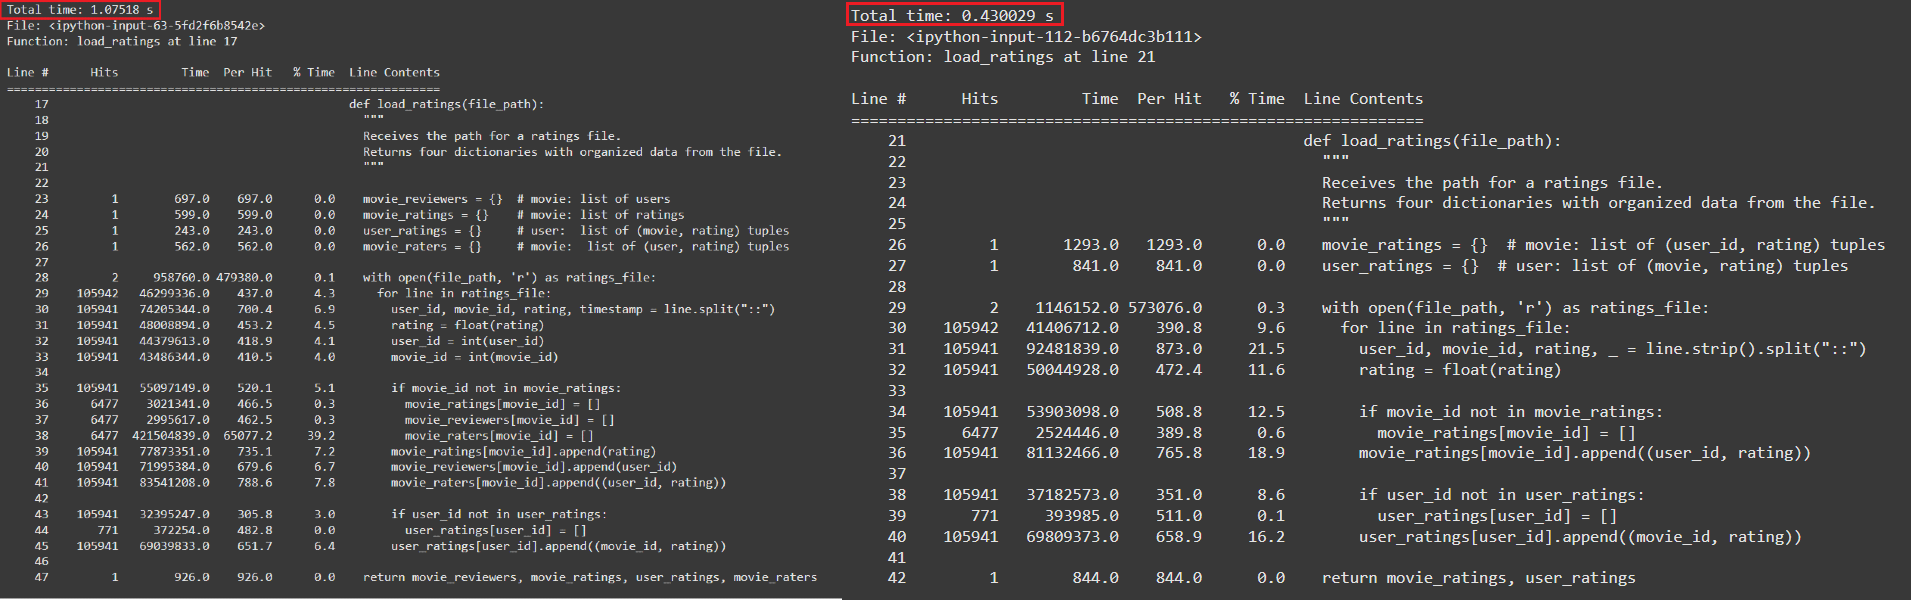

As seen above, the execution time of the load_ratings functions reduced to half.

# Unit Testing Phase (20%)

## ⏩ Κώδικας Unit Testing Phase

Γράψτε στο παρακάτω code cell όλο τον κώδικα που κάνει unit testing σε κάθε unit του refactored κώδικα της προηγούμενης φάσης.

*Υπόδειξη: στην απλή περίπτωση τα δικά σας units είναι μέθοδοι που υλοποιούν τις εντολές που μπορεί να δεχτεί ο Aggregative Movie Preference Analyzer από το χρήστη ΚΑΙ μεθόδους υπολογισμού ενδιάμεσων αποτελεσμάτων όπου και όπως απαιτείται.*

In [ ]:
%%file test_movie_analyzer.py

import sys
import unittest
from unittest.mock import patch
import movie_analyzer as ma

class TestMovieAnalyzer(unittest.TestCase):

  @classmethod
  def setUpClass(cls):
    cls.movies = {
      1: {'title': 'Movie A', 'genres': ['Action', 'Romance']},
      2: {'title': 'Movie B', 'genres': ['Action', 'Romance', 'Comedy']},
      3: {'title': 'Movie C', 'genres': ['Romance']},
      4: {'title': 'Movie D', 'genres': ['Comedy', 'Action']}
    }

    cls.movie_ratings = {
      1: [(100, 5.0), (104, 3.0), (102, 4.5), (103, 1.5)],
      2: [(101, 2.5), (103, 3.5)],
      3: [(104, 2.5), (101, 3.5), (105, 3.5)],
      4: [(103, 4), (102, 4.5), (105, 5)]
    }

    cls.user_ratings = {
      100: [(1, 5.0)],
      101: [(2, 2.5), (3, 3.5)],
      102: [(1, 4.5), (4, 4.5)],
      103: [(1, 1.5), (2, 3.5), (4, 4.0)],
      104: [(1, 3.0), (3, 2.5)],
      105: [(3, 3.5), (4, 5.0)]
    }

  def test_load_ratings(self):
    mock_data = "100::1::5.0::123456\n101::2::4.5::1234567\n"
    file_path = "mock_ratings.dat"

    # Write the mock data to the file
    with open(file_path, 'w') as file:
      file.write(mock_data)

    # Now test the load_ratings function using the created file
    movie_ratings, user_ratings = ma.load_ratings(file_path)

    # Assertions to verify the function's output
    expected_m_r = {
      '1': [('100', 5.0)],
      '2': [('101', 4.5)]
    }

    self.assertEqual(movie_ratings, expected_m_r)

    expected_u_r = {
      '100': [('1', 5.0)],
      '101': [('2', 4.5)]
    }

    self.assertEqual(user_ratings, expected_u_r)

  def test_load_movies(self):
    mock_data = "1::Movie A::Action|Adventure|Sci-Fi\n2::Movie B::Romance|Comedy\n"
    file_path = "mock_movies.dat"

    # Write the mock data to the file
    with open(file_path, 'w') as file:
      file.write(mock_data)

    # Now test the load_ratings function using the created file
    movies = ma.load_movies(file_path)

    expected = {
      '1': {'title': 'Movie A', 'genres': ['Action', 'Adventure', 'Sci-Fi']},
      '2': {'title': 'Movie B', 'genres': ['Romance', 'Comedy']}
    }

    self.assertEqual(movies, expected)

  def test_rating_stats(self):
    result = ma.rating_stats(self.movie_ratings)
    expected = {1: (3.5, 4), 2: (3, 2), 3: (3.166, 3), 4: (4.5, 3)  }

    for movie_id in expected:
      # Extract expected and actual values
      expected_avg, expected_count = expected[movie_id]
      actual_avg, actual_count = result[movie_id]

      # Round the averages and compare both values
      self.assertAlmostEqual(actual_avg, expected_avg, places=2)
      self.assertEqual(actual_count, expected_count)

  def test_rating(self):
    avg_ratings = ma.rating_stats(self.movie_ratings)
    result = ma.rating(3.4, 5, avg_ratings, self.movies)
    expected = [('Movie A', 3.5), ('Movie D', 4.5)]
    self.assertEqual(result, expected)

  def test_top_movies(self):
    avg_ratings = ma.rating_stats(self.movie_ratings)
    result = ma.top_movies(2, avg_ratings, self.movies)
    expected = [('Movie D', 4.5), ('Movie A', 3.5)]
    self.assertEqual(result, expected)

  def test_user_pairs(self):
    result = ma.user_pairs(3, self.movie_ratings, self.movies)
    expected = [(100, 104, 'Movie A'), (100, 102, 'Movie A'), (100, 103, 'Movie A')]
    self.assertEqual(result, expected)

  def test_dominance(self):
    avg_ratings = ma.rating_stats(self.movie_ratings)
    result = ma.dominance(avg_ratings, self.movies)
    expected = [('Movie A', 3.5, 4), ('Movie D', 4.5, 3)]
    self.assertEqual(result, expected)

  def test_iceberg(self):
    avg_ratings = ma.rating_stats(self.movie_ratings)
    result = ma.iceberg(3, 3, avg_ratings, self.movies)
    expected = [('Movie A', 3.5, 4), ('Movie C', 3.166, 3), ('Movie D', 4.5, 3)]

    for expected_value, actual_value in zip(expected, result):
      # Extract expected and actual values
      expected_title, expected_avg, expected_count = expected_value
      actual_title, actual_avg, actual_count = actual_value

      # Compare the title (if needed)
      self.assertEqual(actual_title, expected_title)

      # Round the averages and compare both values
      self.assertAlmostEqual(actual_avg, expected_avg, places=2)
      self.assertEqual(actual_count, expected_count)

  def test_top_users(self):
    result = ma.top_users(2, self.user_ratings)
    expected = [(103, 3), (101, 2)]
    self.assertEqual(result, expected)

  def test_movie_sample(self):
    result = ma.movie_sample(75, self.movies)
    expected = {
      'Action': ['Movie A', 'Movie B'],
      'Romance': ['Movie A', 'Movie B'],
      'Comedy': ['Movie B']
    }

    self.assertEqual(result, expected)

  def test_similar_users(self):
    result = ma.similar_users(0.75, self.movie_ratings)
    for _, _, cs in result:
      self.assertGreaterEqual(cs, 0.75)
      self.assertLessEqual(cs, 1)

if __name__ == '__main__':
  sys.exit(unittest.main())


Overwriting test_movie_analyzer.py


In [ ]:
!python test_movie_analyzer.py

...........
----------------------------------------------------------------------
Ran 11 tests in 0.002s

OK


Γράψτε στο παρακάτω code cell όλο τον κώδικα του Aggregative Movie Preference Analyzer σας με τις αλλαγές που ενδεχομένως προέκυψαν μετά το unit testing (αν υπήρχαν τέτοιες αλλαγές π.χ. επειδή κάποιο unit test έκανε fail και το διορθώσατε).

## ⏩ Τεκμηρίωση και Σχολιασμός Κώδικα της Unit Testing Phase

Γράψτε στο παρακάτω text cell αναφορά που θα περιγράφετε τι κάνει ο κώδικας που αναπτύξατε για να δημιουργήσετε τα Unit Tests στο Unit Testing Phase και περιγράψτε τη λογική βάσει της οποίας στήσατε τα assertions των test σας.

The above unit testing program involves a setUpClass method that constructs mock data that follow the structure in which the actual data is loaded whithin dictionaries. This class method is executed once, at the beginning of the unit testing process. The following two functions test the loading functions responsible for the ratings and movies files. Each one creates a .dat file with two 'records', following the format of the actual ratings and movie records of the given files. The test functions ensure that the data is loaded and organized properly into dictionaries. The rest of the functions pass the mock data created by the setUpClass method, as arguments, into each one of the actual methods, and compare the result with the expected one we've manually constructed. The unit test for 'similar_users' ensures that the computed cosine similarities lie within the appropriate range.

In [ ]:
print ("Καλή Δουλειά!")

Καλή Δουλειά!
